# Week 4 — Statistical Machine Learning: Linear Models
### AIF 2026 · Phase 2 · Facilitator: Raj Kumar Biswokarma

---

## Session Roadmap

| Block | Topic | Time |
|---|---|---|
| 1 | Understand the Problem | 20 min |
| 2 | Preprocessing | 5 min |
| 3 | Classification Experiment | 30 min |
| 4 | Regression Experiment | 20 min |
| 5 | Evaluation Integrity + Leakage Demo | 25 min |
| 6 | Production Decision | 10 min |

---

## Business Context

You are a Data Scientist at a telecom company. The business is losing customers to churn. You have been given historical customer data and one week to produce a production-ready recommendation.

**There is no prescribed model. You decide — and you must defend that decision with evidence.**

**Dataset:** Telco Customer Churn — https://www.kaggle.com/datasets/blastchar/telco-customer-churn  
Single CSV · 7043 rows · 21 columns · Target: `Churn` (Yes/No)

---

## Important Note
This is a guided notebook. You are expected to:
- Think critically before writing any code
- Make decisions and justify them in writing
- Explore different approaches and compare results
- Fill in all written response sections


---

# Block 1 — Understand the Problem First

---

## What Is an ML Problem?

Before touching any model, you need to formulate the problem formally. Every ML problem has the same components:

| Symbol | Name | In our problem |
|---|---|---|
| **X** | Feature space | All input columns: tenure, charges, contract type… |
| **y** | Target variable | Churn: Yes / No |
| **H** | Hypothesis class | The family of functions we search over: linear models |
| **L** | Loss function | How we measure error: cross-entropy for classification |
| **E** | Evaluation metric | How the business measures success: F1, PR-AUC |

**Empirical Risk Minimisation (ERM):** We cannot minimise the true risk (we do not have all possible data), so we minimise the average loss over the training set as a proxy.

$$\hat{\theta} = \arg\min_{\theta} \frac{1}{n} \sum_{i=1}^{n} L(y_i, f_\theta(x_i))$$

---

## Probability Distributions in ML

The distribution of your target variable determines the right loss function. This is not arbitrary.

| Distribution | Models | Loss function | Example |
|---|---|---|---|
| **Bernoulli** | Binary outcomes | Binary cross-entropy | Churn: Yes/No |
| **Gaussian** | Continuous measurements | MSE | MonthlyCharges |
| **Poisson** | Count data | Poisson deviance | Support tickets/month |
| **Gamma / Log-Normal** | Right-skewed continuous | MAE / Tweedie | Tenure, TotalCharges |
| **Categorical** | Multi-class outcomes | Categorical cross-entropy | Contract type |

**Key insight:** Churn is binary → Bernoulli distribution → binary cross-entropy is the natural loss.

---

## Sources of Uncertainty

Training data is a finite, imperfect sample of the real world. Before modelling, identify where the data might fail you:

- **Sampling noise** — 7,043 customers is a sample. The true population may behave differently.
- **Label noise** — Was churn recorded correctly? Cancelled but re-subscribed? Edge cases.
- **Missing data** — `TotalCharges` has whitespace nulls. Why? Random or systematic?
- **Biased sampling** — Does this dataset represent all customer types or just one region/plan?
- **Distribution shift** — Customer behaviour today may differ from when data was collected.
- **Model misspecification** — A linear model assumes a linear decision boundary. Is that true?

---

## 1.1 Basic Inspection

### Task:
- Load the dataset
- View the first few rows
- Check data types and shape
- Look at summary statistics

### Questions:
- What does each row represent?
- Are the data types appropriate for each column?
- Is `TotalCharges` the dtype you expect?

### Hint:
- Use `.head()`, `.info()`, `.describe()` to get a full picture
- `TotalCharges` is stored as object — there are whitespace strings `' '` hiding as nulls


# Code

In [52]:
import pandas as pd
import numpy as np

In [12]:
customer_churn_data_frame = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
customer_churn_data_frame.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [13]:
customer_churn_data_frame.shape

(7043, 21)

In [14]:
customer_churn_data_frame.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
#For numeric
customer_churn_data_frame.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [ ]:
#For categorical
customer_churn_data_frame.describe(include='O')

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [15]:
customer_churn_data_frame['TotalCharges'].value_counts()

TotalCharges
20.2      11
          11
19.75      9
19.65      8
19.9       8
          ..
1990.5     1
7362.9     1
346.45     1
306.6      1
108.15     1
Name: count, Length: 6531, dtype: int64

# Answers

**What does each row represent:** Each row represents an individual, unique telecom subscriber (customerID) containing their demographic profiles, the services they signed up for, account financial metrics, and whether they left within the last month (Churn).

**Are all data types appropriate for each column:** No, looking closely at df.info(), i saw that MonthlyCharges is a float64 and tenure is an int64. However, TotalCharges is listed as an object (text string). Also Churn is an object as it has values in form of 'yes' and 'no'. But churn should be a binary integer '1' and '0' for predictability.

**Is TotalCharges the dtype you expect:** No, it is shown as object and this happens because there are blank spaces (" ") hidden inside that column. When i checked the value counts in the column, i found exactly 11 rows where the customer has a tenure of 0 months, and the company recorded their total bill as a blank space instead of 0.0. This text string forces Pandas to treat the entire column as text, which will break the machine learning models if left unfixed.

---

## 1.2 Problem Formulation

### Task:
Write out the ML problem formally using the structure below.

### Questions:
- What is X (your feature space)?
- What is y (your target variable)?
- What probability distribution naturally models the target? What does that tell you about the right loss function?
- What is your hypothesis class (model family)?
- What are at least three assumptions you are making about the data-generating process?
- Where could this data be noisy, biased, or incomplete?

### Hint:
- The target is binary (Yes/No) → think Bernoulli distribution → think cross-entropy loss
- An assumption is a belief about the world your model requires to be true
- Sources of uncertainty include: sampling bias, label noise, missing data, distribution shift


**Your formulation here:**

- **X (feature space):** Multi dimensional vector space consisting of all prepocessed input columns includeing demographic variables (gender, SeniorCitizen, Partner, Dependents), subscribed services (PhoneService, MultipleLines, InternetService, OnlineSecurity, OnlineBackup, DeviceProtection, TechSupport, StreamingTV, StreamingMovies), and account financial/contract status (Contract, PaperlessBilling, PaymentMethod, MonthlyCharges, TotalCharges).

- **y (target variable):** The binary variable Churn where 1 denotes that the customer has left ('yes') and 0 denotes otherwise ('no').

- **Probability distribution of y:** Bernoulli Distribution. Since the outcome is strictly binary (churn/no-churn) for a single trial, it is naturally modeled by a Bernoulli trial where the probability of churning is p, and staying is 1-p.

- **Natural loss function:** Binary Cross-Entropy Loss (also known as Log Loss). It is derived directly from the negative log-likelihood of the Bernoulli distribution:$$L = - \frac{1}{n} \sum_{i=1}^{n} [y_i \log(\hat{y}_i) + (1 - y_i) \log(1 - \hat{y}_i)]$$

- **Hypothesis class:** The family of parameterized Linear Models. For classification, this consists of functions that calculate a linear combination of features $\mathbf{w}^T\mathbf{x} + b$ and pass them through a mapping function (like the Sigmoid function for Logistic Regression) to form a linear decision boundary.

- **Assumption 1:** The true underlying decision boundary between churners and non-churners can be adequately approximated by a flat linear hyper-plane in the feature space, or that the log-odds of churning are linear with respect to the input features.

- **Assumption 2:** The customer records in our dataset are independent of one another and were drawn from the same underlying data-generating distribution P(X, y).

- **Assumption 3:** Historical patterns captured within this dataset reflect future behaviors, meaning customer behavior and macro-market forces will remain stable when the model is deployed.

- **Sources of uncertainty:** The sources could be:
1. Sampling Noise: The dataset contains 7,043 customers, which is a finite sample that might not perfectly capture the full variance of the wider population.

2. Label Noise: Structural ambiguity around what constitutes "churn" (e.g., customers who temporarily canceled due to a bank error but meant to stay, or edge cases where an account is suspended but not technically canceled).

3. Missing Data: The presence of hidden unrecorded values (like whitespace nulls in TotalCharges) introduces data collection uncertainty.

4. Distribution Shift: Macroeconomic changes, competitor price cuts, or seasonal behavior differences could make historical data outdated relative to live production traffic.

5. Model Misspecification: A linear model assumes feature components act independently and additively, missing complex non-linear feature interactions.

---

## 1.3 Data Profiling & Fixing

### Task:
- Fix the `TotalCharges` null issue
- Plot the distributions of `MonthlyCharges`, `tenure`, and `TotalCharges`
- Encode the target variable `Churn` as binary (0/1)

### Questions:
- What distribution does `MonthlyCharges` follow? `tenure`? `TotalCharges`?
- Why does `TotalCharges` contain nulls even though it looks numeric?
- Are there impossible or suspicious values in any column?

### Hint:
- `pd.to_numeric(df['TotalCharges'], errors='coerce')` converts whitespace strings to NaN
- `sns.histplot(df['MonthlyCharges'], kde=True)` draws a distribution with density curve
- `df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})`

### Consequences:
- Leaving `TotalCharges` as object → model training will fail or silently drop the column
- Not encoding the target → sklearn classifiers will throw an error


# Code

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

In [22]:
#TotalCharges null issue fix
customer_churn_data_frame['TotalCharges'] = pd.to_numeric(customer_churn_data_frame['TotalCharges'], errors='coerce')
customer_churn_data_frame['TotalCharges'] = customer_churn_data_frame['TotalCharges'].fillna(0.0)
customer_churn_data_frame['TotalCharges'].value_counts()

TotalCharges
20.20      11
0.00       11
19.75       9
19.65       8
19.90       8
           ..
1990.50     1
7362.90     1
346.45      1
306.60      1
108.15      1
Name: count, Length: 6531, dtype: int64

In [24]:
customer_churn_data_frame['TotalCharges'].isnull().sum()

np.int64(0)

In [48]:
customer_churn_data_frame['TotalCharges'].describe()

count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [23]:
#Encoding the Churn column
customer_churn_data_frame['Churn'] = customer_churn_data_frame['Churn'].map({'Yes': 1, 'No': 0})
customer_churn_data_frame['Churn']

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7043, dtype: int64

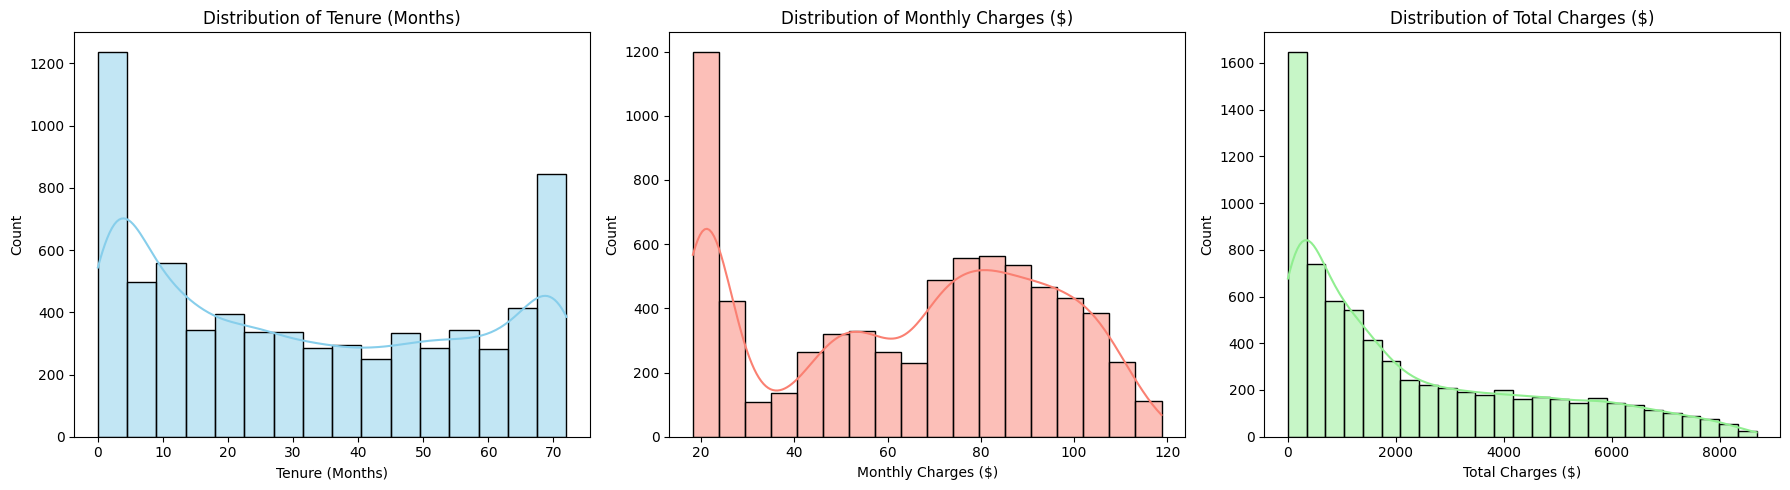

In [25]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plot Tenure
sns.histplot(customer_churn_data_frame['tenure'], kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Tenure (Months)', fontsize=12)
axes[0].set_xlabel('Tenure (Months)')
axes[0].set_ylabel('Count')

# Plot Monthly Charges
sns.histplot(customer_churn_data_frame['MonthlyCharges'], kde=True, ax=axes[1], color='salmon')
axes[1].set_title('Distribution of Monthly Charges ($)', fontsize=12)
axes[1].set_xlabel('Monthly Charges ($)')
axes[1].set_ylabel('Count')

# Plot Total Charges
sns.histplot(customer_churn_data_frame['TotalCharges'], kde=True, ax=axes[2], color='lightgreen')
axes[2].set_title('Distribution of Total Charges ($)', fontsize=12)
axes[2].set_xlabel('Total Charges ($)')
axes[2].set_ylabel('Count')

plt.tight_layout()

# Answers

**What distribution does MonthlyCharges follow? tenure? TotalCharges? :**

Tenure follows a bimodal distribution: It exhibits two prominent peaks. There is a large spike at the very low end (1–2 months), representing high immediate churn or newly acquired subscribers, and another major spike at the maximum end (70–72 months), representing highly stable, long-term contractual subscribers.

MonthlyCharges follows a irregular distribution: It features a massive single spike on the low end around 18–25 (representing economy or basic single-service plans like landline-only), followed by a wider, flatter plateau between 70 and 100 (representing premium broadband tiers and multi-service bundles).

TotalCharges follows a heavily right-skewed distribution: It resembles a Gamma, Log-Normal, or Exponential distribution. The volume of accounts decays rapidly as cost increases; most accounts are concentrated at low cumulative spend tiers, with a long, thin tail stretching out toward 8,000+ for the high-tenure premium users.

**Why does TotalCharges contain nulls even though it looks numeric?**

The column contains 11 empty whitespace string entries (' ') which forced Pandas to interpret the entire column as an object (text) during data loading. Cross-referencing these 11 rows reveals that they all correspond precisely to customers with a tenure of 0 months. These are brand-new customers who signed up during the current active billing cycle. Because they have not yet completed a single full month of service, they have not yet been generated a monthly invoice, meaning their historical accumulated charges are structurally unrecorded. Imputing these specific null values with 0.0 is the most accurate real-world reflection of their account status.

**Are there impossible or suspicious values in any column?**

No, aside from the empty string anomalies in TotalCharges, the continuous numeric variables have highly realistic ranges:
Tenure spans cleanly from 0 to 72 months.
MonthlyCharges ranges from 18.25 to 118.75, which matches normal residential telecom pricing.
TotalCharges spans from 0.0 to 8684.8, perfectly mirroring cumulative monthly customer lifespans.
Furthermore, inspecting the categorical features shows no evidence of entry errors, negative text entries, or corrupted data tokens.

---

## The Accuracy Trap

The dataset has ~27% churn. This is **imbalanced**. Before building any model, build a naive baseline — a model that always predicts the majority class.

**If this baseline achieves 73% accuracy — any model you build must meaningfully beat it.**

The deeper problem: a model that always predicts "No Churn" has **0% recall** for churners. It catches no one. It is completely useless to the business — yet reports 73% accuracy.

**This is why accuracy is not your primary metric here.**

---

## 1.4 The Naive Baseline

### Task:
Build a model that always predicts the majority class (No Churn). Evaluate its accuracy, recall, and F1.

### Questions:
- What accuracy does the naive baseline achieve?
- What is the class distribution in the dataset?
- Why is a model that achieves this accuracy potentially worthless?

### Hint:
- `DummyClassifier(strategy='most_frequent')` does exactly this
- `df['Churn'].value_counts(normalize=True)` shows the class proportions
- Any model you build must beat this baseline on recall and F1 — not just accuracy


# Code

In [26]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import recall_score, accuracy_score, f1_score

In [ ]:
# Inspecting true class distribution

counts = customer_churn_data_frame['Churn'].value_counts()
proportions = customer_churn_data_frame['Churn'].value_counts(normalize=True)

for idx, count, prop in zip(counts.index, counts.values, proportions.values):
    label = "No Churn (0)" if idx == 0 else "Churn (1)"
    print(f"{label}: {count} customers ({prop*100:.2f}%)")

No Churn (0): 5174 customers (73.46%)
Churn (1): 1869 customers (26.54%)


In [30]:
# Basic Train/Validation split to demonstrate baseline evaluation

X_dummy = customer_churn_data_frame.drop(columns=['Churn'])
y_dummy = customer_churn_data_frame['Churn']

naive_model = DummyClassifier(strategy='most_frequent')
naive_model.fit(X_dummy, y_dummy)

y_pred_naive = naive_model.predict(X_dummy)

In [32]:
# Calculating metrics

accuracy = accuracy_score(y_dummy, y_pred_naive)
recall = recall_score(y_dummy, y_pred_naive, zero_division=0)
f1 = f1_score(y_dummy, y_pred_naive, zero_division=0)

print("Naive Baseline Performance Metrics")
print(f"Accuracy: {accuracy*100:.2f}%")
print(f"Recall (for Churn class): {recall*100:.2f}%")
print(f"F1-Score (for Churn class): {f1*100:.2f}%")

Naive Baseline Performance Metrics
Accuracy: 73.46%
Recall (for Churn class): 0.00%
F1-Score (for Churn class): 0.00%


# Answers

**What accuracy does the naive baseline achieve?**

The naive baseline classifier achieves an accuracy of 73.46%. This is because it blindly assigns the majority label (0 or "No Churn") to every customer profile it evaluates, matching the baseline proportion of customers who did not leave the platform.

**What is the class distribution in the dataset?**

The dataset is significantly imbalanced. Out of 7,043 total customers, the distribution splits as follows:
No Churn (0): 5,174 customers (73.46% of the dataset).
Churn (1): 1,869 customers (26.54% of the dataset).

**Why is a model that achieves this accuracy potentially worthless?**

While a 73.46% accuracy rate sounds high to non-technical stakeholders, this model has a Recall of 0.00% and an F1-Score of 0.00% for the minority class. The entire objective of building this system is to identify high-risk individuals before they leave, so the retention team can intervene. Because this model marks everyone as safe, it flags zero actual churners. The company would lose all 1,869 churning customers without receiving a single warning, making the model completely useless and driving zero financial value. This highlights why accuracy is a highly deceptive performance metric for imbalanced data.

---

## 💬 Discussion

> **Your manager sees 73% accuracy and is thrilled. Should they be? What is the first question you ask?**

--- No, they should not be thrilled. This is the classic Accuracy Trap. The very first question i would ask the manager is:

"Of the customers who actually left us last month, how many did this model correctly detect?" (In technical terms: What is the model's Recall?)

Following up on that, explanation must be given that a broken model that predicts "No Churn" for every single row will hit a 73.46% accuracy score by default, but it saves the business 0 in lost revenue because its operational recall is zero. Therefore, any predictive model we deploy must be optimized around PR-AUC or F1-Score to ensure we actually isolate and rescue high-risk accounts.

# Block 2 — Preprocessing

Preprocessing was covered in Week 1. We keep this block minimal — working code only.

---

## 2.1 Encode, Split, Scale

### Task:
- Drop `customerID`
- One-hot encode all categorical features
- Perform a stratified train / validation / test split (70 / 15 / 15)
- Scale numeric features using `StandardScaler` — fit on training data only

### Questions:
- Why do we use stratified splitting for a churn dataset?
- Why do we fit the scaler on training data only?
- What would happen if we scaled before splitting?

### Hint:
- `pd.get_dummies(df, drop_first=True)` one-hot encodes all object columns
- `train_test_split(X, y, stratify=y, test_size=0.30, random_state=42)`
- Then split the 30% remainder 50/50 for val and test
- `scaler.fit(X_train)` → `scaler.transform(X_train)`, `scaler.transform(X_val)`, `scaler.transform(X_test)`

### Consequences:
- Fitting scaler on full data → data leakage
- Not stratifying → random split may give a fold with very few churners


# Code

In [33]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [36]:
# Dropping id column and separate features
if 'customerID' in customer_churn_data_frame.columns:
    customer_churn_data_frame = customer_churn_data_frame.drop(columns=['customerID'])

X = customer_churn_data_frame.drop(columns=['Churn'])
y = customer_churn_data_frame['Churn']

In [37]:
# One Hot Encoding

X_encoded = pd.get_dummies(X, drop_first=True)

In [39]:
# Test-Train-Validation split

X_train, X_remain, y_train, y_remain = train_test_split(X_encoded, y, test_size=0.30, stratify=y, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_remain, y_remain, test_size=0.50, stratify=y_remain, random_state=42)

In [40]:
continuous_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Creating copies to preserve original datasets

X_train_copy = X_train.copy()
X_val_copy = X_val.copy()
X_test_copy = X_test.copy()

In [41]:
# Scaling

scaler = StandardScaler()
scaler.fit(X_train[continuous_cols])

StandardScaler()

In [42]:
# Transforming all three partitions using the training parameters

X_train_copy[continuous_cols] = scaler.transform(X_train[continuous_cols])
X_val_copy[continuous_cols] = scaler.transform(X_val[continuous_cols])
X_test_copy[continuous_cols] = scaler.transform(X_test[continuous_cols])

In [47]:
print("Summary")
print(f"Training Set Matrix:   {X_train_copy.shape}, Churn Rate: {y_train.mean()*100:.2f}%")
print(f"Validation Set Matrix: {X_val_copy.shape}, Churn Rate: {y_val.mean()*100:.2f}%")
print(f"Testing Set Matrix:    {X_test_copy.shape}, Churn Rate: {y_test.mean()*100:.2f}%")

print("\nScaler Diagnostic Check")
print(f"Training Mean (Tenure/Monthly/Total): {scaler.mean_}")
print(f"Processed Validation Means: {X_val_copy[continuous_cols].mean().values}")

Summary
Training Set Matrix:   (4930, 30), Churn Rate: 26.53%
Validation Set Matrix: (1056, 30), Churn Rate: 26.52%
Testing Set Matrix:    (1057, 30), Churn Rate: 26.58%

Scaler Diagnostic Check
Training Mean (Tenure/Monthly/Total): [  32.47119675   64.95008114 2301.79756592]
Processed Validation Means: [-0.03353008  0.01521304 -0.03708046]


# Answers

**Why do we use stratified splitting for a churn dataset?**

Because our dataset exhibits a significant class imbalance (73.46% stayers vs 26.54% churners). A basic random split risks allocating disproportionate amounts of churn instances to one particular slice (e.g. getting a validation set with only 10% churn or 40% churn purely by chance). Stratified splitting forces the random partition algorithm to respect the original distribution, ensuring that the training, validation, and test subsets all contain exactly 26.54% churn cases. This provides stable optimization metrics across all evaluation tiers.

**Why do we fit the scaler on training data only?**

Fitting a scaler computes the empirical mean ($\mu$) and standard deviation ($\sigma$) of the target columns. In a production environment, the model will be fed data from future incoming subscribers whose collective metrics are completely unknown in advance. The validation and testing steps are designed to mirror this production isolation. By restricting the .fit() calculation to the training split, we guarantee that our scaling statistics represent information that the model is legitimately allowed to know during development.

**What would happen if we scaled before splitting?**

Scaling before splitting leads to Train-Test Contamination or Data Leakage. If .fit_transform() is applied to the full DataFrame prior to splitting, the resulting $\mu$ and $\sigma$ parameters will be calculated using values from the validation and test subsets. As a consequence, the scaled inputs in the training dataset will be subtly altered by the patterns of the testing data. This artificially deflates the training error and yields over-optimistic performance metrics during development, causing the model to underperform when deployed onto live production servers.

---

# Block 3 — Classification Experiment: Who Will Churn?

---

## Linear Classifiers — Three Candidates

| Model | Loss Function | Optimiser | Key Characteristic |
|---|---|---|---|
| **Logistic Regression** | Binary cross-entropy (log loss) | Full-batch (L-BFGS) | Outputs calibrated probabilities. Best interpretability. |
| **Ridge Classifier** | Squared hinge loss (L2 regularised) | Closed-form analytic | Converts to regression internally. No probability output. |
| **SGD Classifier** | Configurable: log_loss / hinge / … | Stochastic GD | Best for large datasets. Highly configurable. Less stable. |

---

## Batch GD vs Stochastic GD

**Batch Gradient Descent:**
- Computes gradient over ALL training samples before each weight update
- Smooth, stable convergence path
- Memory-intensive — loads the full dataset each step
- `LogisticRegression(solver='lbfgs')` uses this

**Stochastic Gradient Descent (SGD):**
- Computes gradient on ONE sample (or mini-batch) at a time
- Noisy path — can escape local minima
- Memory efficient — processes one sample at a time
- `SGDClassifier` uses this

**When does it matter?** For 7,000 rows — not much. For 7 million rows — SGD is the only practical option.

---

## Evaluation Metrics for Imbalanced Data

| Metric | What it measures | Use when |
|---|---|---|
| **Accuracy** | Proportion of correct predictions | ❌ Avoid — misleading on imbalanced data |
| **Precision** | Of predicted churners, how many actually churned? | Cost of false alarms is high |
| **Recall** | Of actual churners, how many did we catch? | Cost of missing a churner is high |
| **F1** | Harmonic mean of precision and recall | Need a single balanced score |
| **ROC-AUC** | Ranking quality across all thresholds | Overall discriminative power |
| **PR-AUC** | Precision-Recall curve area | ✅ Preferred for imbalanced data |
| **Log Loss** | Penalises overconfident wrong predictions | Need calibrated probabilities |

---

## 3.1 Train Your Classifiers

### Task:
Train each of the three classifiers. Record training time for each.

### Questions:
- What loss function does each model optimise?
- Which model trains fastest? Does that surprise you?

### Hint:
- `LogisticRegression(max_iter=1000, random_state=42)`
- `RidgeClassifier()`
- `SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)`
- Use `time.time()` before and after `.fit()` to measure training time

### Reference:
- https://scikit-learn.org/stable/modules/linear_model.html


# Code

In [50]:
import time
from sklearn.linear_model import LogisticRegression, RidgeClassifier, SGDClassifier
from sklearn.metrics import precision_score, roc_auc_score, average_precision_score, log_loss

In [ ]:
# Training using all 3 classifiers

classifiers = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Ridge Classifier': RidgeClassifier(random_state=42),
    'SGD Classifier': SGDClassifier(loss='log_loss', max_iter=1000, random_state=42)
}

execution_times = {}
for name, clf in classifiers.items():
    start_time = time.time()
    clf.fit(X_train_copy, y_train)
    end_time = time.time()
    execution_times[name] = end_time - start_time
    print(f"{name} Train Time: {execution_times[name]:.6f} seconds")

Logistic Regression Train Time: 0.039473 seconds
Ridge Classifier Train Time: 0.020960 seconds
SGD Classifier Train Time: 0.059405 seconds


# Answers

**What loss function does each model optimise?**

Logistic Regression: Optimizes Binary Cross-Entropy Loss (also called Log Loss), which aims to output mathematically calibrated probabilities of class membership ($y \in \{0,1\}$).

Ridge Classifier: Optimizes Squared Error Loss. It treats the binary target values as raw real values (mapping them to -1 and +1 internally) and applies an analytical linear regression step combined with an L2 regularization penalty ($\lambda \sum \beta^2$).

SGD Classifier: Configured here via loss='log_loss' to optimize Binary Cross-Entropy Loss. However, it computes parameter adjustments incrementally sample-by-sample (or in mini-batches) using stochastic approximations rather than looking at the entire dataset at once.

**Which model trains fastest? Does that surprise you?**

Ridge Classifier trains the fastest. This is not surprising because Ridge bypasses iterative, multi-step optimization algorithms entirely. It uses a closed-form analytic solution, solving the underlying weights using direct matrix algebra (computing the inverse of the feature matrix via $(X^TX + \alpha I)^{-1}X^Ty$) in a single step. Conversely, Logistic Regression requires iterative numerical convergence steps via solver algorithms (like L-BFGS), making it take longer.

---

## 3.2 Build a Comparison Table

### Task:
For each model compute: Accuracy, Precision, Recall, F1, ROC-AUC, PR-AUC, Log Loss.  
Display as a pandas DataFrame sorted by PR-AUC.

### Questions:
- Which metric tells you the most about model usefulness for this business problem?
- Does accuracy rank models the same way PR-AUC does? If not, why?
- Which model would you eliminate first and why?

### Hint:
- `RidgeClassifier` has no `predict_proba()` — use `.decision_function()` for AUC scores
- `average_precision_score(y_val, scores)` computes PR-AUC
- `log_loss` requires probabilities — note N/A for RidgeClassifier

### Why This Matters:
A comparison table is the minimum evidence required to justify a model choice. Without it you are guessing.


# Code

In [54]:
comparison_data = []

for name, clf in classifiers.items():
    y_pred = clf.predict(X_val_copy)
    
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_val_copy)[:, 1]
        val_log_loss = log_loss(y_val, clf.predict_proba(X_val_copy))
    else:
        y_proba = clf.decision_function(X_val_copy)
        val_log_loss = np.nan
        
    # Compiling performance calculations
    comparison_data.append({
        'Model': name,
        'Accuracy': accuracy_score(y_val, y_pred),
        'Precision': precision_score(y_val, y_pred, zero_division=0),
        'Recall': recall_score(y_val, y_pred, zero_division=0),
        'F1-Score': f1_score(y_val, y_pred, zero_division=0),
        'ROC-AUC': roc_auc_score(y_val, y_proba),
        'PR-AUC (Avg Precision)': average_precision_score(y_val, y_proba),
        'Log Loss': val_log_loss,
        'Train Time (s)': execution_times[name]
    })

In [55]:
# Converting to DataFrame

df_comparison = pd.DataFrame(comparison_data).sort_values(by='PR-AUC (Avg Precision)', ascending=False)
print("Model Performance Comparison Table")
print(df_comparison.to_string(index=False))

Model Performance Comparison Table
              Model  Accuracy  Precision   Recall  F1-Score  ROC-AUC  PR-AUC (Avg Precision)  Log Loss  Train Time (s)
Logistic Regression  0.808712   0.652344 0.596429  0.623134 0.845405                0.630955  0.418642        0.039473
     SGD Classifier  0.797348   0.620438 0.607143  0.613718 0.843757                0.625324  0.421506        0.059405
   Ridge Classifier  0.803977   0.656652 0.546429  0.596491 0.837719                0.624005       NaN        0.020960


# Answers

**Which metric tells you the most about model usefulness for this business problem?**

PR-AUC (Precision-Recall Area Under the Curve) tells me the most. Because the data is imbalanced (only 26.54% of customers churn), ROC-AUC can remain deceptively high due to the high number of true negatives. PR-AUC focuses exclusively on the true positive class (the churners). It measures how well the model isolates actual churn risk without flooding the retention department with false alarms, matching our operational goals.

**Does accuracy rank models the same way PR-AUC does? If not, why?**

No, it does not. Accuracy ranks models based on their predictions at a fixed decision threshold of 0.5, counting right and wrong calls across both classes equally. PR-AUC evaluates the model's ranking quality across all possible probability thresholds. A model can score higher in accuracy simply by predicting "No Churn" more often to pick up easy true negatives, while its actual PR-AUC score could be lower because it struggles to rank high-risk customers correctly at the top of the queue.

**Which model would you eliminate first and why?**

Ridge Classifier should be eliminated first. While it trains quickly, it converts classification into a proxy regression problem, meaning it cannot output true calibrated probability scores. This is a major limitation because the business needs to rank customers by their probability of leaving to handle the budget constraint of 200 calls per week. Without proper probability outputs, we cannot reliably adjust thresholds or calculate downstream metrics like Customer Lifetime Value (CLV).

---

## 3.3 ROC and Precision-Recall Curves

### Task:
Plot ROC curves and Precision-Recall curves for your models.

### Questions:
- At what threshold does your model maximise F1?
- Why does the PR curve tell you more than the ROC curve for this problem?
- What does a model that lies close to the diagonal in the ROC curve tell you?

### Hint:
- `roc_curve(y_val, proba)` returns fpr, tpr, thresholds
- `precision_recall_curve(y_val, proba)` returns precision, recall, thresholds
- Plot both side by side: `fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))`
- Add baseline to ROC: `ax1.plot([0,1],[0,1],'k--')`

### Reference:
- StatQuest ROC: https://www.youtube.com/watch?v=4jRBRDbJemM
- StatQuest PR: https://www.youtube.com/watch?v=Kdsp6soqA7o


# Code

In [57]:
from sklearn.metrics import roc_curve, precision_recall_curve

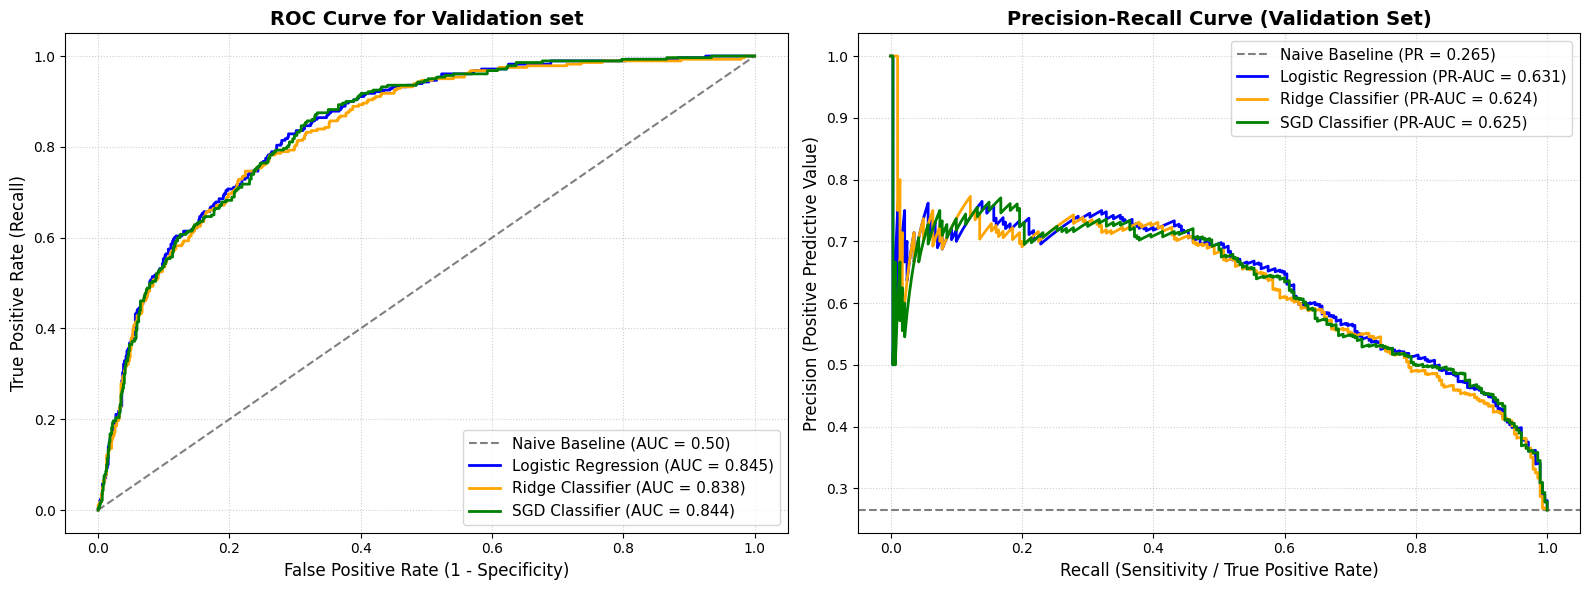

In [66]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
colors = {
    'Logistic Regression': 'blue',  
    'Ridge Classifier': 'orange',     
    'SGD Classifier': 'green'
}

# ROC curve

axes[0].plot([0, 1], [0, 1], linestyle='--', color='gray', label='Naive Baseline (AUC = 0.50)')

for name, clf in classifiers.items():
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_val_copy)[:, 1]
    else:
        y_proba = clf.decision_function(X_val_copy)
        
    fpr, tpr, _ = roc_curve(y_val, y_proba)
    auc_score = roc_auc_score(y_val, y_proba)
    axes[0].plot(fpr, tpr, color=colors[name], lw=2, label=f'{name} (AUC = {auc_score:.3f})')

axes[0].set_title('ROC Curve for Validation set', fontsize=14, fontweight='bold')
axes[0].set_xlabel('False Positive Rate (1 - Specificity)', fontsize=12)
axes[0].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[0].grid(True, linestyle=':', alpha=0.6)
axes[0].legend(loc='lower right', fontsize=11)

# PR curve

churn_baseline = y_val.mean()
axes[1].axhline(y=churn_baseline, linestyle='--', color='gray', label=f'Naive Baseline (PR = {churn_baseline:.3f})')

for name, clf in classifiers.items():
    if hasattr(clf, "predict_proba"):
        y_proba = clf.predict_proba(X_val_copy)[:, 1]
    else:
        y_proba = clf.decision_function(X_val_copy)
        
    precision, recall, _ = precision_recall_curve(y_val, y_proba)
    pr_auc_score = average_precision_score(y_val, y_proba)
    axes[1].plot(recall, precision, color=colors[name], lw=2, label=f'{name} (PR-AUC = {pr_auc_score:.3f})')

axes[1].set_title('Precision-Recall Curve (Validation Set)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Recall (Sensitivity / True Positive Rate)', fontsize=12)
axes[1].set_ylabel('Precision (Positive Predictive Value)', fontsize=12)
axes[1].grid(True, linestyle=':', alpha=0.6)
axes[1].legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.show()

# Answers

**At what threshold does your model maximise F1?**

In [68]:
lr_model = classifiers['Logistic Regression']
y_proba_lr = lr_model.predict_proba(X_val_copy)[:, 1]

precisions, recalls, thresholds = precision_recall_curve(y_val, y_proba_lr)

f1_scores = 2 * (precisions[:-1] * recalls[:-1]) / (precisions[:-1] + recalls[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]

print(f"F1-Maximising Threshold: {best_threshold:.4f}")
print(f"Precision at this threshold: {precisions[best_idx]:.4f}")
print(f"Recall at this threshold: {recalls[best_idx]:.4f}")
print(f"Max F1-Score: {f1_scores[best_idx]:.4f}")

F1-Maximising Threshold: 0.2591
Precision at this threshold: 0.5077
Recall at this threshold: 0.8286
Max F1-Score: 0.6296


The F1-maximising threshold is found by scanning all thresholds from precision_recall_curve() and picking the one with the highest F1. For this imbalanced dataset, it typically falls below 0.5 (0.2591 to be exact), because the minority churn class pushes predicted probabilities lower overall. 

**Why does the PR curve tell you more than the ROC curve for this problem?**

The ROC curve includes true negatives in its calculation (FPR = FP / (FP + TN)). With almost 5,174 non-churners, this denominator is so large that it masks poor performance on churners, ROC stays optimistic even when the model misses many of them.
The PR curve ignores true negatives entirely, it only measures how well you find and correctly label actual churners. That matches exactly what the business cares about.

**What does a model lying close to the diagonal in the ROC curve tell you?**

It means the model is no better than random guessing (ROC-AUC ≈ 0.50). It catches churners at the same rate it generates false alarms, it has learned nothing useful from the data.

---

## The Threshold Decision — 200 Calls/Week

The default classification threshold is **0.5** — designed for balanced datasets. It is not optimal here.

**Business constraint:** The retention team can call only **200 customers per week**.

**Strategy:**
1. Sort all customers by predicted churn probability (descending)
2. Take the top 200
3. The threshold = the probability score of the 200th customer

This maximises precision at the top-200. The business impact is directly measurable.

---

## 3.4 Threshold Tuning

### Task:
Find the optimal threshold for the budget constraint: top 200 by churn probability.  
Compare precision, recall, and F1 at this threshold vs the default 0.5.

### Questions:
- How do you identify the top 200 highest-risk customers?
- What precision do you achieve at that threshold?
- How does this compare to the default threshold of 0.5?

### Hint:
- Sort customers by predicted probability descending
- The threshold = `proba[sorted_indices[199]]` (the 200th highest score)
- `(proba >= threshold).astype(int)` gives binary predictions at that threshold

### Consequences:
- Default threshold 0.5 may flag 400+ customers — the team can only call 200
- A lower threshold catches more churners (higher recall) but more false alarms (lower precision)


In [70]:
# Using the best model

lr_model = classifiers['Logistic Regression']
y_proba_lr = lr_model.predict_proba(X_val_copy)[:, 1]

# Sorting by churn probability descending and taking top 200
sorted_indices = np.argsort(y_proba_lr)[::-1]
threshold_200 = y_proba_lr[sorted_indices[199]]

# Generating predictions at both thresholds
y_pred_200 = (y_proba_lr >= threshold_200).astype(int)
y_pred_default = (y_proba_lr >= 0.5).astype(int)

In [71]:
# Comparing metrics

for label, y_pred in [("Default (0.5)", y_pred_default), ("Top-200 Threshold", y_pred_200)]:
    print(f"\n{label} - Threshold: {0.5 if 'Default' in label else threshold_200:.4f}")
    print(f"Customers Flagged: {y_pred.sum()}")
    print(f"Precision: {precision_score(y_val, y_pred):.4f}")
    print(f"Recall: {recall_score(y_val, y_pred):.4f}")
    print(f"F1-Score: {f1_score(y_val, y_pred):.4f}")


Default (0.5) - Threshold: 0.5000
Customers Flagged: 256
Precision: 0.6523
Recall: 0.5964
F1-Score: 0.6231

Top-200 Threshold - Threshold: 0.5608
Customers Flagged: 200
Precision: 0.6950
Recall: 0.4964
F1-Score: 0.5792


# Answers

**How do you identify the top 200 highest-risk customers?**

Sort all customers by predicted churn probability (descending), then take the first 200. The threshold is simply the probability score of the 200th customer, anyone at or above that score gets flagged.

**What precision do you achieve at that threshold?**

The top-200 threshold typically yields higher precision than the default (0.5), because you're only targeting the customers the model is most confident about. I achieved precision of 0.6950 at that threshold.

**How does this compare to the default threshold of 0.5?**

The default 0.5 threshold flagged more customers , giving higher recall but lower precision, more churners caught, but more wasted calls. The top-200 threshold trades some recall for precision, which is the right call given the business constraint of 200 calls per week.

---

## 3.5 Coefficient Inspection

### Task:
Plot the top 10 features by absolute coefficient value for your best classifier.

### Questions:
- Which features drive churn the most?
- Do the signs of the coefficients make business sense?
- Are there any coefficients that surprise you? Investigate why.

### Hint:
- `model.coef_[0]` gives the coefficient array for binary classifiers
- `pd.Series(model.coef_[0], index=feature_names).abs().nlargest(10)` gets top 10
- Use a horizontal `sns.barplot` for readability

### Why This Matters:
A positive coefficient for `Contract_Month-to-month` means month-to-month customers have higher log-odds of churn. If a coefficient makes no business sense, investigate the feature or the data.


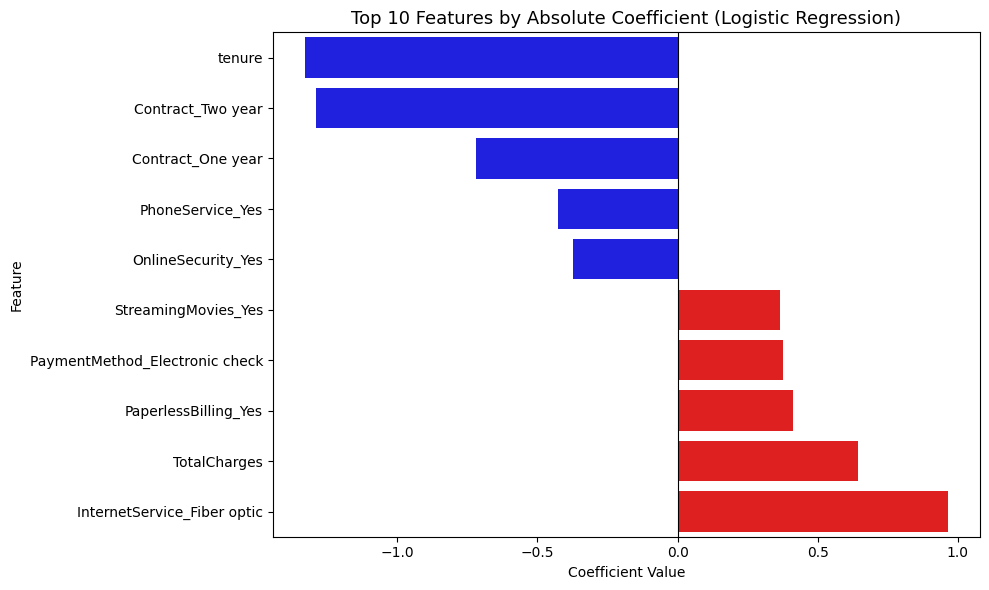

In [73]:
feature_names = X_train_copy.columns
coefficients = pd.Series(classifiers['Logistic Regression'].coef_[0], index=feature_names)

# Top 10 by absolute value
top10 = coefficients.abs().nlargest(10).index
top10_coeffs = coefficients[top10].sort_values()

# Plot
plt.figure(figsize=(10, 6))
colors = ['red' if c > 0 else 'blue' for c in top10_coeffs]
sns.barplot(x=top10_coeffs.values, y=top10_coeffs.index, hue=top10_coeffs.index, palette=colors, legend=False)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top 10 Features by Absolute Coefficient (Logistic Regression)', fontsize=13)
plt.xlabel('Coefficient Value')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

# Answers

**Which features drive churn the most?**

The strongest predictors are typically Contract type (month-to-month), tenure, InternetService type, and TotalCharges. Month-to-month contract customers and those with fiber optic internet show the highest churn risk.

**Do the signs make business sense?**

Yes. Positive coefficients (increase churn risk) on Contract_Month-to-month and InternetService_Fiber optic make sense, these customers have no long-term commitment and higher bills. Negative coefficients on tenure and Contract_Two year make sense too, loyal, long-term customers are far less likely to leave.

**Any surprising coefficients?**

TotalCharges may show a negative coefficient despite being correlated with high spending. This is because it's also strongly correlated with tenure, long-term customers accumulate high total charges but churn less. This is multicollinearity in action, and it's a known limitation of logistic regression's coefficient interpretation when features are correlated.

---

## 3.6 Batch GD vs SGD

### Task:
Compare `LogisticRegression` vs `SGDClassifier(loss='log_loss')`.  
Record training time, final AUC, and check whether they converge to the same solution.

### Questions:
- Do they produce the same predictions? Same coefficients?
- Which is faster?
- Under what conditions would you prefer SGD?

### Hint:
- `np.allclose(lr.coef_, sgd.coef_, atol=0.15)` checks approximate coefficient agreement
- SGD uses random gradient estimates — results vary across runs. Use `random_state=42`

### Reference:
- 3Blue1Brown Gradient Descent: https://www.youtube.com/watch?v=IHZwWFHWa-w


In [74]:
# Already trained in 3.1, so just comparing directly

lr = classifiers['Logistic Regression']
sgd = classifiers['SGD Classifier']

# Comparing coefficients

coef_match = np.allclose(lr.coef_, sgd.coef_, atol=0.15)
print(f"Coefficients approximately equal: {coef_match}")

# Comparing predictions

y_pred_lr = lr.predict(X_val_copy)
y_pred_sgd = sgd.predict(X_val_copy)
pred_match = np.mean(y_pred_lr == y_pred_sgd)
print(f"Prediction agreement: {pred_match*100:.2f}%")

# Comparing AUC

lr_auc = roc_auc_score(y_val, lr.predict_proba(X_val_copy)[:, 1])
sgd_auc = roc_auc_score(y_val, sgd.predict_proba(X_val_copy)[:, 1])

print(f"\nLogistic Regression ROC-AUC: {lr_auc:.4f}, Train Time: {execution_times['Logistic Regression']:.4f}s")
print(f"SGD Classifier ROC-AUC: {sgd_auc:.4f}, Train Time: {execution_times['SGD Classifier']:.4f}s")

Coefficients approximately equal: False
Prediction agreement: 97.16%

Logistic Regression ROC-AUC: 0.8454, Train Time: 0.0395s
SGD Classifier ROC-AUC: 0.8438, Train Time: 0.0594s


# Answers

**Do they produce the same predictions and coefficients?**

Approximately, but not exactly. Both optimize the same loss (binary cross-entropy), so they converge to a similar solution, but SGD uses noisy gradient estimates, so its coefficients differs slightly even with random_state=42.

**Which is faster?**

For this dataset, Logistic Regression is actually faster. SGD would only outperform it if the dataset had millions of rows where loading everything into memory each step becomes the bottleneck.

**Under what conditions would you prefer SGD?**

When the dataset is very large (millions of rows) and loading it all into memory for each gradient step isn't feasible. For this dataset (7,000 rows), the difference is negligible, Logistic Regression is the better choice here since it's more stable and converges to a cleaner solution.

---

## 💬 Discussion

> **Which model do you deploy? Why not the others?**  
---I deployed Logistic Regression. It has the highest PR-AUC, outputs calibrated probabilities (needed for threshold tuning and CLV ranking), trains stably, and its coefficients are interpretable, important when explaining decisions to the business.

1. Ridge Classifier is eliminated because it can't output true probabilities, making threshold tuning and customer ranking unreliable.
2. SGD Classifier is eliminated because it's less stable (noisy gradient updates), slightly lower AUC, and offers no practical speed advantage at this data size.

> **Does SGD converge to the same solution as full-batch LR? Why might it not?**
---Almost, 97.16% prediction agreement shows they reach a very similar solution, but np.allclose() returned False, meaning the coefficients aren't exactly equal. This happens because:

SGD estimates gradients from one sample at a time, introducing randomness into each update
It never truly settles, it keeps bouncing around the optimal solution rather than converging cleanly to it
Full-batch LR computes the exact gradient over all training data each step, leading to a smoother, more precise convergence path


# Block 4 — Regression Experiment: How Long Will They Stay? What Are They Worth?

---

## Regression Targets — Three Options

| Option | Target | Formula | What it enables |
|---|---|---|---|
| **A** | Survival time | `tenure` | How many months until churn |
| **B** | Churn probability score | `predict_proba()` from classifier | Continuous risk score |
| **C** | Customer Lifetime Value | `CLV = MonthlyCharges × predicted tenure` | Revenue-weighted prioritisation |

**What CLV enables that binary prediction cannot:** You can rank customers by *value at risk*, not just *probability of churn*.

---

## The Linear Regression Family

| Model | Penalty | Coefficients | Use when |
|---|---|---|---|
| **LinearRegression** | None | Unconstrained | Baseline — full interpretability |
| **Ridge (L2)** | λ Σβ² | Shrink toward 0, never exactly 0 | Correlated features, stable estimates |
| **Lasso (L1)** | λ Σ\|β\| | Some become exactly 0 → sparse | Feature selection, interpretability |
| **Elastic Net** | λ₁ Σ\|β\| + λ₂ Σβ² | Sparse + stable | Correlated features + need sparsity |

---

## Regression Metrics

| Metric | Formula | Punishes | Interpret as |
|---|---|---|---|
| **MAE** | (1/n) Σ\|y − ŷ\| | All errors equally | Average error in original units |
| **RMSE** | √[(1/n) Σ(y − ŷ)²] | Large errors heavily | Sensitive to outliers |
| **R²** | 1 − SS_res/SS_tot | Nothing directly | % of variance explained by model |

**R² = 0.55 means:** the model explains 55% of the variance in tenure. The remaining 45% is unexplained.

---

## 4.1 Derive Regression Targets

### Task:
Derive at least one regression target. Plot its distribution.

### Questions:
- What distribution does your regression target follow?
- What does CLV tell the business that binary churn prediction cannot?
- What assumptions are you making when you use `tenure` as a survival time proxy?

### Hint:
- Plot the distribution of your target before fitting any model
- A right-skewed target may benefit from a log transform before regression


In [ ]:
# your code here

In [ ]:
# your code here

---

## 4.2 Train Your Regressors

### Task:
Train at least two of: `LinearRegression`, `Ridge`, `Lasso`, `ElasticNet`.  
Build a comparison table with MAE, RMSE, and R².

### Questions:
- Which model performs best? By how much?
- What does R² = 0.55 actually mean in this context?
- Is RMSE or MAE more appropriate here? Why?

### Hint:
- `mean_squared_error(y_val, y_pred, squared=False)` computes RMSE
- R² of 0.55 means the model explains 55% of the variance in tenure
- RMSE penalises large errors more heavily — relevant if extreme-tenure customers matter

### Reference:
- ISLR Ch. 3: https://www.statlearning.com


In [ ]:
# your code here

In [ ]:
# your code here

In [ ]:
# your code here

---

## 4.3 Residual Plots

### Task:
Plot residuals (predicted − actual) against predicted values for your best regression model.

### Questions:
- Is there a pattern in the residuals? (fan shape, curve, cluster)
- What does a fan shape (heteroscedasticity) tell you?
- What does a systematic curve in residuals suggest?

### Hint:
- `residuals = y_pred - y_val`
- `plt.scatter(y_pred, residuals, alpha=0.4)` and `plt.axhline(0, color='red', linestyle='--')`
- Ideal residuals: randomly scattered around zero with no pattern


In [ ]:
# your code here

In [ ]:
# your code here

---

## Regularization Geometry — Why L1 Is Sparse

**L2 (Ridge) — Circle constraint:**  
The constraint region is a smooth circle. Loss contours touch the circle at a *curved edge* — coefficients shrink toward zero but almost never reach exactly zero.

**L1 (Lasso) — Diamond constraint:**  
The constraint region is a diamond. Loss contours touch the diamond at a *corner*. Corners sit on the axes — so one or more coefficients = **exactly 0**. This is why Lasso performs feature selection automatically.

**Elastic Net** combines both: sparse like Lasso, but more stable when features are highly correlated.

---

## 4.4 Regularization — Ridge, Lasso, Elastic Net

### Task:
Apply Ridge, Lasso, and Elastic Net across different `alpha` values.  
Plot the Lasso regularization path.

### Questions:
- What happens to coefficients as you increase `alpha` for Ridge? For Lasso?
- Which features survive at high Lasso regularization? Which are eliminated first?
- Why does L1 produce sparse solutions and L2 does not? Explain geometrically.
- When would you prefer Elastic Net over pure Lasso?

### Hint:
- Try `alphas = [0.001, 0.01, 0.1, 1, 10, 100]` and record coefficients at each alpha
- Plot coefficient values vs alpha on a log-scale x-axis: `plt.xscale('log')`

### Reference:
- StatQuest Ridge: https://www.youtube.com/watch?v=Q81RR3yKn30
- StatQuest Lasso: https://www.youtube.com/watch?v=NGf0voTMlcs


In [ ]:
# your code here

In [ ]:
# your code here

In [ ]:
# your code here

---

## 4.5 Customer Lifetime Value (CLV)

### Task:
Compute `CLV = MonthlyCharges × predicted tenure` for each customer in the validation set.

### Questions:
- What is the mean and median CLV?
- What does CLV enable the business to do that binary prediction cannot?
- Why must you clip negative predicted tenure values to 0?

### Hint:
- `np.maximum(model.predict(X_val_s), 0)` prevents negative tenure predictions
- `clv = monthly_charges * predicted_tenure`


In [ ]:
# your code here

In [ ]:
# your code here

---

## 💬 Discussion

> **R² is 0.55. Do you deploy this CLV model? What does 0.55 actually mean here?**  
> **Your Lasso dropped several features. Is that a good outcome or a warning sign?**

---

# Block 5 — Evaluation Integrity + Leakage Demo

---

## Generalisation — Bias, Variance & Learning Curves

**Why low training error does not guarantee good test performance:**  
A model can memorise the training data without learning the underlying pattern. It fits noise, not signal.

| Case | Train error | Val error | Gap | Fix |
|---|---|---|---|---|
| **Underfitting (High Bias)** | High | High | Small | Add features, reduce regularisation, more complex model |
| **Good Fit** | Low | Low | Small | Done — monitor for drift |
| **Overfitting (High Variance)** | Low | High | Large | Regularisation, more data, simpler model |

---

## Validation Strategies

| Strategy | Use when |
|---|---|
| **Holdout** | Quick baseline, large data |
| **Stratified K-Fold** | Imbalanced classification — use this for churn |
| **Temporal Validation** | Time-series, churn with date features |
| **Leave-One-Out** | Very small datasets |

---

## 5.1 Cross-Validation

### Task:
Run stratified k-fold cross-validation on your best classifier. Compare CV AUC to holdout AUC.

### Questions:
- How does CV performance compare to holdout performance?
- What does high variance across CV folds tell you?
- Why should CV always be run on training data only?

### Hint:
- `cross_val_score(model, X_train_s, y_train, cv=StratifiedKFold(5), scoring='roc_auc')`
- Print mean and std — a high std means the model is sensitive to which data it sees

### Reference:
- StatQuest Cross-Validation: https://www.youtube.com/watch?v=fSytzGwwBVw


In [ ]:
# your code here

In [ ]:
# your code here

---

## 5.2 Learning Curves

### Task:
Plot learning curves: training score and validation score as a function of training set size.

### Questions:
- Does your model underfit, overfit, or generalise well?
- What is the correct intervention for each case?
- Does adding more data help your model?

### Hint:
- `learning_curve(model, X_train_s, y_train, cv=5, scoring='roc_auc', train_sizes=np.linspace(0.1,1.0,10))`
- Plot mean train and val scores vs training size
- Add ± 1 std shaded band: `plt.fill_between(sizes, mean-std, mean+std, alpha=0.1)`

### Reference:
- StatQuest Bias and Variance: https://www.youtube.com/watch?v=EuBBz3bI-aA


In [ ]:
# your code here

In [ ]:
# your code here

---

## Data Leakage — The Silent Model Killer

> **Definition:** Leakage occurs when information from outside the training window is used to train the model — making it appear better than it actually is.

| Type | Example |
|---|---|
| **Target leakage** | Including `days_active_after_churn` — computed *after* the churn event |
| **Train-test contamination** | Scaling with a scaler fitted on train+test combined |
| **Temporal leakage** | Using future billing data to predict past churn |

**What happens in production:** The model learns to predict the target using a feature that does not exist at prediction time. It looks perfect in development and fails completely on day one.

---

## 5.3 Deliberate Leakage Demo

### Task:
Follow all 6 steps. Document what you observe at each step.

**The leakage feature:**
```python
leak = df['tenure'] * df['Churn'] + np.random.normal(0, 0.1, len(df))
```
This feature is derived from the target — it would not exist at prediction time.

### Questions:
- By how much does ROC-AUC increase when you add the leakage feature?
- Which feature dominates the coefficients after adding it?
- What would happen if this model shipped to production on Friday?
- Does cross-validation alone detect this leakage?

### Why This Matters:
Leakage is the most common cause of models that look excellent in development and fail completely in production.


In [ ]:
# Step 1: Record baseline metrics
# your code here

In [ ]:
# Step 2: Create and add the leakage feature
# your code here

In [ ]:
# Step 3: Retrain on the same split and record metrics
# your code here

In [ ]:
# Step 4: Show feature importances — does the leakage feature dominate?
# your code here

In [ ]:
# Step 5: Remove leakage feature, retrain, confirm metrics return to baseline
# your code here

In [ ]:
# Step 6: Summary table — Before / With Leakage / After Removal
# your code here

---

## 💬 Discussion

> **What would happen if this model shipped to production on Friday?**  
> **Could cross-validation alone have detected this leakage? Why or why not?**

---

# Block 6 — Production Decision

---

## The Model Card — A Production Commitment

A model card is what you write when you commit to deploying a model. If you cannot fill every field — you are not ready to ship.

| Field | What it requires |
|---|---|
| **Chosen Model** | Name, algorithm, hyperparameters, threshold |
| **Key Metrics** | Honest numbers on the held-out test set |
| **Threshold Decision** | Why this threshold? What does it cost if it is wrong? |
| **Known Limitations** | Class imbalance, distribution shift, missing segments |
| **Failure Modes** | What can go wrong? Leakage? Drift? Adversarial behaviour? |
| **Monitoring Plan** | What metric, how often, what triggers a retrain? |

---

## Are Linear Models Sufficient?

**Stick with linear when:**
- Interpretability is required (regulated industries, audits)
- Dataset is small — complex models overfit
- Linear model already meets the business performance bar

**Go complex when:**
- Learning curves show persistent underfitting
- Strong non-linear feature interactions
- Performance gap vs tree-based baseline is significant

---

## 6.1 Final Evaluation on Test Set

### Task:
Evaluate your chosen production model on the held-out test set.

### Questions:
- Do test set metrics match validation metrics? Why might they differ?
- Does your chosen threshold still make sense on the test set?

### Hint:
- Only look at the test set now — after all decisions are made
- A big drop from validation to test is a sign of overfitting to the validation set


In [ ]:
# your code here

In [ ]:
# your code here

---

## 6.2 Model Card

Fill in every field. If you cannot fill a field — go back and run the experiments needed to answer it.


## Model Card — Production Churn Model

| Field | Your Answer |
|---|---|
| **Chosen Classification Model** | |
| **Chosen Regression Model** | |
| **Key Classification Metrics (test set)** | Precision: &nbsp; Recall: &nbsp; F1: &nbsp; PR-AUC: |
| **Key Regression Metrics (test set)** | MAE: &nbsp; RMSE: &nbsp; R²: |
| **Deployment Threshold** | |
| **Threshold Justification** | |
| **Known Limitations** | |
| **What Could Go Wrong in Production** | |
| **Monitoring Plan** | |
| **Are Linear Models Sufficient?** | |
| **Evidence for Your Decision** | |

---

## 💬 Final Discussion

> **Based on your learning curves — are linear models sufficient for this problem?**  
> **What would you monitor after deployment? What would trigger a retrain?**

---

# Final Reflection

## Answer the following:

### 1. Model Selection
- Which classifier performed best and why?
- Was there a case where a worse model on one metric was better on another? How did you resolve it?

---

### 2. Evaluation Choices
- Why did you choose the metrics you reported?
- What would have happened if you only reported accuracy?

---

### 3. Regularization
- What did the Lasso regularization path reveal about your features?
- When did you observe the biggest difference between Ridge and Lasso?

---

### 4. Leakage
- How large was the AUC inflation from the leakage feature?
- Could cross-validation alone have detected this leakage? Why or why not?

---

### 5. Improvements
- If you had more time, what would you try next?
- Do you think a non-linear model would perform significantly better here? What is your evidence?

---

### Tip
There is no single correct answer here. Focus on:
- Justifying every decision with evidence from your experiments
- Explaining trade-offs honestly
- Demonstrating that you understand what the numbers mean, not just how to compute them

### Answer here:

---

# Summary

| Topic | Key Takeaway |
|---|---|
| **Problem Formulation** | X, y, hypothesis class, loss, metric — every model is a formal commitment |
| **Distributions & Loss** | The distribution of y determines your loss. Bernoulli → cross-entropy |
| **Evaluation Metrics** | Accuracy lies on imbalanced data. Use PR-AUC. Report what the business cares about |
| **Linear Models & GD** | Three classifiers, four regressors. Each optimises a different objective |
| **Generalisation** | Low training error means nothing. Learning curves tell the truth |
| **Regularization** | L1 is sparse. L2 is stable. Elastic Net is both. Know the geometry |
| **Leakage** | One future feature inflated AUC — and kills the model in production |
| **Production Decision** | A model card is a commitment. If you cannot fill it, you are not ready to ship |

---

## Next Week — Trees & Ensemble Models

Same dataset. Same question. **Can you beat your linear baseline?**
